In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3

In [3]:
df_final = pd.read_csv("./licencias_2024_limpio_P.csv")
df = df_final.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18915 entries, 0 to 18914
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   sexo                           18915 non-null  object 
 1   fechanacimiento                18915 non-null  object 
 2   descripcionprovinciadomicilio  18915 non-null  object 
 3   estado                         18915 non-null  int64  
 4   fechaaltasolicitud             18915 non-null  object 
 5   temporada                      18915 non-null  int64  
 6   modalidad                      18915 non-null  object 
 7   categoria                      18915 non-null  object 
 8   complementos                   5080 non-null   object 
 9   importeseguro                  18915 non-null  float64
 10  cuota_socio                    18915 non-null  int64  
 11  nsocio                         18915 non-null  int64  
 12  discapacidad                   18915 non-null 

**Análisis univariante**

*Estadísticos de centralidad*

In [4]:
df['edad'].mean()
df['edad'].median()
df['edad'].mode()

df['edad'].quantile([0.25, 0.5, 0.75])
df['edad'].quantile([0.1, 0.9])

0.1    29.0
0.9    70.0
Name: edad, dtype: float64

*Estadísticos de dispersión*

In [5]:
df['edad'].var()
df['edad'].std()
df['edad'].min()
df['edad'].max()
df['edad'].max() - df['edad'].min()

np.int64(89)

Gráficas

*Variable categórica*

In [6]:
df['sexo'].value_counts()
df['sexo'].value_counts(normalize=True)

sexo
MASCULINO    0.670209
FEMENINO     0.329791
Name: proportion, dtype: float64

*Histograma*

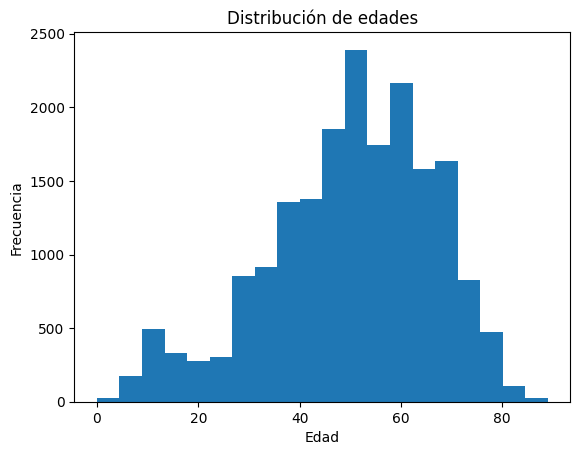

In [7]:
plt.hist(df['edad'], bins=20)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de edades')
plt.show()

*Función densidad de probabilidad*

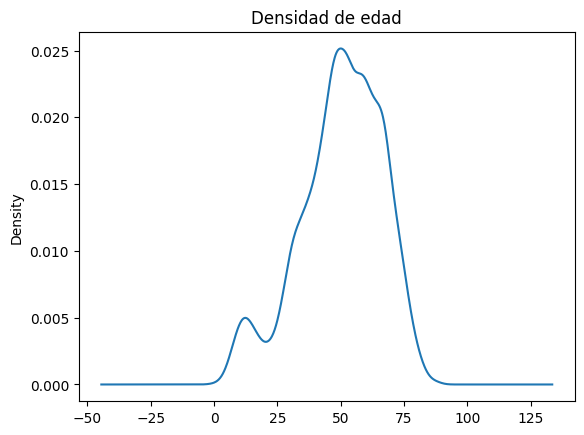

In [8]:
df['edad'].plot(kind='kde')
plt.title('Densidad de edad')
plt.show()

*Boxplot*

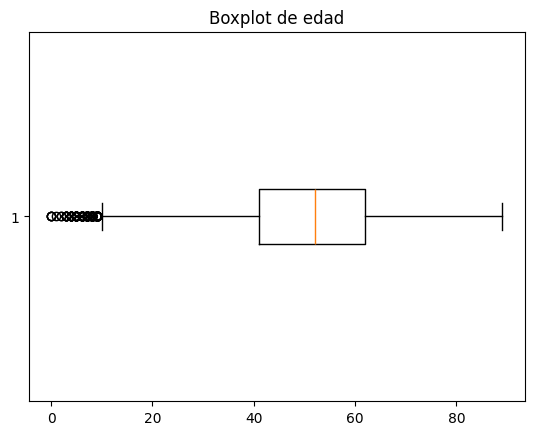

In [9]:
plt.boxplot(df['edad'], vert=False)
plt.title('Boxplot de edad')
plt.show()

*Categórica*

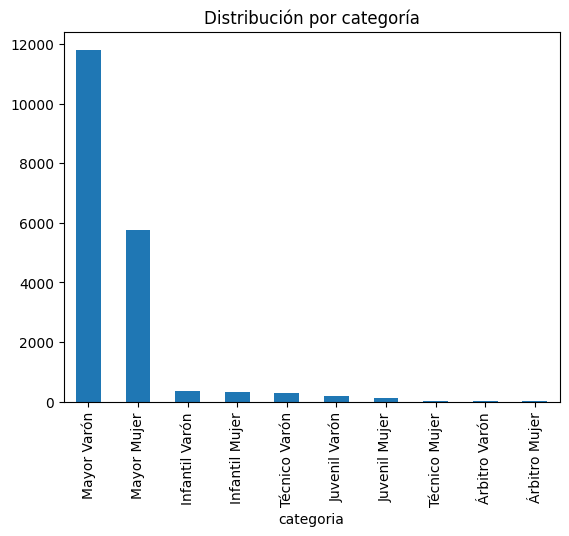

In [10]:
df['categoria'].value_counts().plot(kind='bar')
plt.title('Distribución por categoría')
plt.show()

**Análisis bivariante**

*Groupby*

In [11]:
df.groupby('sexo')['edad'].mean()

sexo
FEMENINO     49.315486
MASCULINO    50.603061
Name: edad, dtype: float64

In [12]:
df.groupby('categoria')['cuota_socio'].mean()

categoria
Infantil Mujer    0.323899
Infantil Varón    0.278378
Juvenil Mujer     0.335878
Juvenil Varón     0.525000
Mayor Mujer       2.340063
Mayor Varón       2.069687
Técnico Mujer     1.000000
Técnico Varón     1.750000
Árbitro Mujer     0.571429
Árbitro Varón     1.294118
Name: cuota_socio, dtype: float64

In [13]:
df.groupby('descripcionprovinciadomicilio').size()

descripcionprovinciadomicilio
-                   699
ALBACETE             17
ALICANTE             13
ALMERÍA               5
ASTURIAS             26
BADAJOZ               8
BARCELONA            52
BURGOS               15
CANTABRIA            21
CASTELLÓN            11
CIUDAD REAL          28
CORUÑA, A            17
CUENCA               16
CÁCERES               9
CÁDIZ                 5
CÓRDOBA               3
GIRONA                6
GRANADA               6
GUADALAJARA         193
GUIPUZCOA            22
HUELVA                3
HUESCA               37
ILLES BALEARS        15
JAÉN                  3
LEÓN                 10
LLEIDA                9
LUGO                  4
MADRID            17154
MELILLA               1
MURCIA               10
MÁLAGA               12
NAVARRA              22
OURENSE               2
PALENCIA              5
PALMAS, LAS           6
PONTEVEDRA            4
RIOJA, LA            11
SALAMANCA             5
SEGOVIA              61
SEVILLA               5
SORIA     

Gráficas

*Scatter plot*

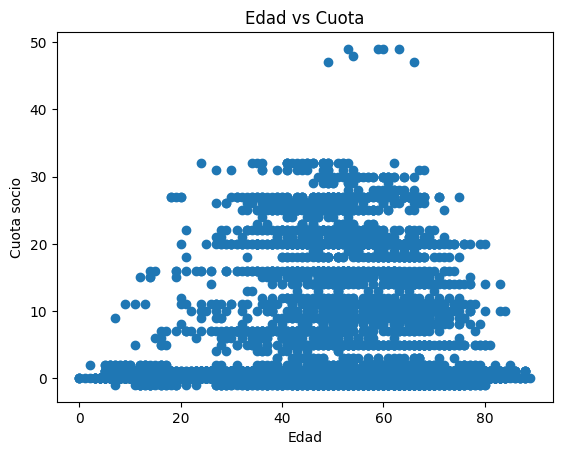

In [14]:
plt.scatter(df['edad'], df['cuota_socio'])
plt.xlabel('Edad')
plt.ylabel('Cuota socio')
plt.title('Edad vs Cuota')
plt.show()

*Diagrama de barras*

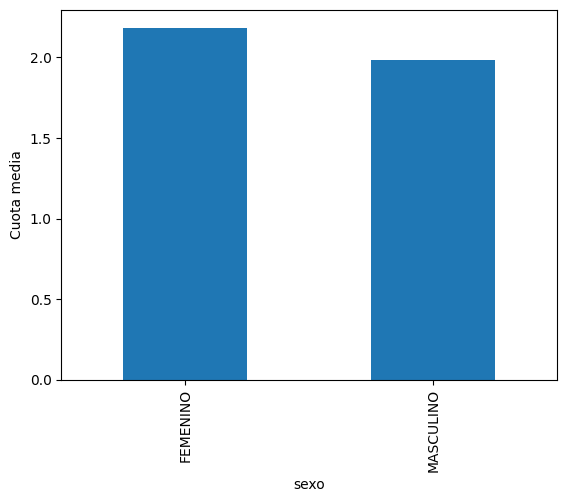

In [15]:
df.groupby('sexo')['cuota_socio'].mean().plot(kind='bar')
plt.ylabel('Cuota media')
plt.show()

*Tabla cruzada*

In [16]:
pd.crosstab(df['sexo'], df['modalidad'])

modalidad,A,A6,AU,B,B6,C,D,D Comp.,E,E Comp.,OT
sexo,,,,,,,,,,,
FEMENINO,927,57,226,4369,78,416,86,2,0,1,76
MASCULINO,1012,71,355,9623,152,1097,243,1,6,2,115


In [17]:
pd.crosstab(df['sexo'], df['modalidad'], normalize='index')

modalidad,A,A6,AU,B,B6,C,D,D Comp.,E,E Comp.,OT
sexo,,,,,,,,,,,
FEMENINO,0.148605,0.009138,0.036230,0.700385,0.012504,0.066688,0.013786,0.000321,0.000000,0.000160,0.012183
MASCULINO,0.079830,0.005601,0.028003,0.759091,0.011990,0.086535,0.019169,0.000079,0.000473,0.000158,0.009072
